# Exploratory Data Analysis

This notebook explores the cleaned dataset produced in `I-cleaning.ipynb`: one row per country-year, combining World Bank development indicators with the Heritage Foundation's Index of Economic Freedom for 185 countries between 2001 and 2025 (`data/processed/wb_economic_freedom_merged.csv`).

The goal is to investigate how economic freedom (property rights, government integrity, trade freedom, and other sub-components) relates to real-world development outcomes (GDP per capita, life expectancy, unemployment, and more), through descriptive statistics, trends over time, and visualisation.

**Parts covered in this notebook:**
1. Imports, loading the cleaned dataset, and initial inspection
2. Global and regional trends over time
3. Relationship between economic freedom and development outcomes
4. Correlation analysis across indicators
5. Key findings and takeaways

<table align="left">
  <tr>
    <td>
      <a href="https://colab.research.google.com/github/ValentimPiazera/wb-economic-freedom/blob/main/notebooks/II-analysis.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
      </a>
    </td>
    <td>
      <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ValentimPiazera/wb-economic-freedom/blob/main/notebooks/II-analysis.ipynb">
        <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle"/>
      </a>
    </td>
  </tr>
</table>

> **Note:** if you're running this notebook on Google Colab or Kaggle, run the cell below first, it clones the repository so that the `src/` module and data files are available.
>
> On **Kaggle**, make sure Internet access is enabled: *Settings → Internet → On*.

In [ ]:
# Setup: clone repo when running on Colab/Kaggle (skip if running locally!)
import os

IN_COLAB_OR_KAGGLE = (
    "google.colab" in str(get_ipython())
    or "kaggle" in os.environ.get("KAGGLE_URL_BASE", "").lower()
)

if IN_COLAB_OR_KAGGLE:
    if not os.path.exists("wb-economic-freedom"):
        !git clone https://github.com/ValentimPiazera/wb-economic-freedom.git
    %cd wb-economic-freedom/notebooks
    # Not preinstalled on Colab/Kaggle; used for label placement in Part III.
    !pip install -q adjustText

## Part I | Imports, Loading, and Initial Inspection

Load the cleaned dataset from `data/processed/wb_economic_freedom_merged.csv` and get a first look at its shape, columns, and data types before starting the analysis.

In [ ]:
import sys

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter, LogLocator

sys.path.append("..")

from src import viz

In [3]:
df = pd.read_csv("../data/processed/wb_economic_freedom_merged.csv")

df.head()

,Country Name,Country Code,Year,Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),"Foreign direct investment, net inflows (% of GDP)",GDP (current US$),GDP growth (annual %),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)","Population, total",...,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,GDP per capita (current US$),Continent
0,Afghanistan,AFG,2001,0.9402,0.024169,2.813572e+09,-9.431974,NaN,55.511,20284307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138.706822,Asia
1,Afghanistan,AFG,2002,0.9388,1.306950,3.825701e+09,28.600001,NaN,56.225,21378117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178.954088,Asia
2,Afghanistan,AFG,2003,1.0172,1.278493,4.520947e+09,8.832278,NaN,57.171,22733049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,198.871116,Asia
3,Afghanistan,AFG,2004,0.9024,3.577104,5.224897e+09,1.414118,NaN,57.810,23560654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,221.763654,Asia
4,Afghanistan,AFG,2005,1.2763,4.368673,6.203257e+09,11.229715,12.686269,58.247,24404567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,254.184249,Asia


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 25 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Country Name                                                         4581 non-null   str    
 1   Country Code                                                         4581 non-null   str    
 2   Year                                                                 4581 non-null   int64  
 3   Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)    4313 non-null   float64
 4   Foreign direct investment, net inflows (% of GDP)                    4256 non-null   float64
 5   GDP (current US$)                                                    4522 non-null   float64
 6   GDP growth (annual %)                                                4498 non-null   float64
 7   Inflation, consum

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,4581.0,2.013028e+03,7.201594e+00,2.001000e+03,2.007000e+03,2.013000e+03,2.019000e+03,2.025000e+03
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),4313.0,1.820587e+02,8.556816e+02,2.000000e-04,2.984300e+00,1.409680e+01,7.294110e+01,1.312473e+04
"Foreign direct investment, net inflows (% of GDP)",4256.0,7.311693e+00,4.974529e+01,-1.303108e+03,1.190340e+00,2.809549e+00,5.594378e+00,1.282607e+03
GDP (current US$),4522.0,4.037714e+11,1.743695e+12,6.493585e+07,8.034019e+09,3.074509e+10,1.926441e+11,3.076970e+13
GDP growth (annual %),4498.0,3.530866e+00,5.533162e+00,-5.440209e+01,1.501833e+00,3.664719e+00,5.879458e+00,8.682675e+01
"Inflation, consumer prices (annual %)",4263.0,6.459680e+00,1.667305e+01,-1.685969e+01,1.731484e+00,3.604522e+00,7.189209e+00,5.572018e+02
"Life expectancy at birth, total (years)",4396.0,7.047783e+01,8.628947e+00,3.153000e+01,6.493825e+01,7.190087e+01,7.700554e+01,8.549634e+01
"Population, total",4581.0,3.930915e+07,1.424973e+08,3.319400e+04,2.376722e+06,8.720283e+06,2.764936e+07,1.463866e+09
"School enrollment, secondary (% gross)",3177.0,8.274280e+01,2.850791e+01,3.347850e+00,6.709386e+01,8.975031e+01,1.014880e+02,1.640798e+02
"Unemployment, total (% of total labor force) (modeled ILO estimate)",4433.0,7.739484e+00,5.963704e+00,1.000000e-01,3.607000e+00,5.832000e+00,1.020700e+01,3.732000e+01


## Part II | Top 10s

More like a trivia, this parts covers graphics about top 10 most and least in some aspects.

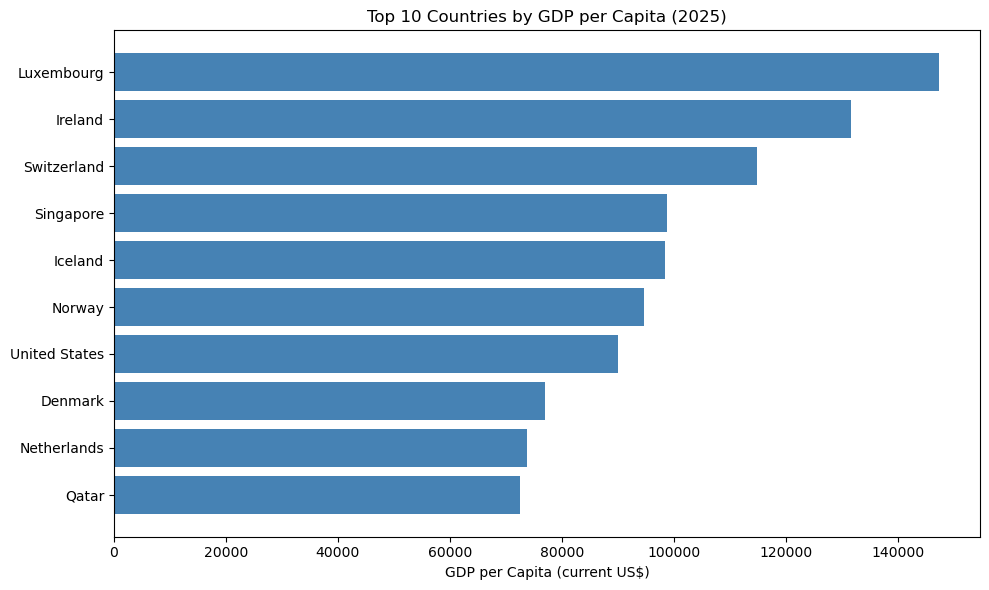

In [6]:
latest_year = df["Year"].max()
top10_gdp = df[df["Year"] == latest_year].nlargest(
    10, "GDP per capita (current US$)"
)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_gdp["Country Name"],
    top10_gdp["GDP per capita (current US$)"],
    color="steelblue",
)
plt.xlabel("GDP per Capita (current US$)")
plt.title(f"Top 10 Countries by GDP per Capita ({latest_year})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

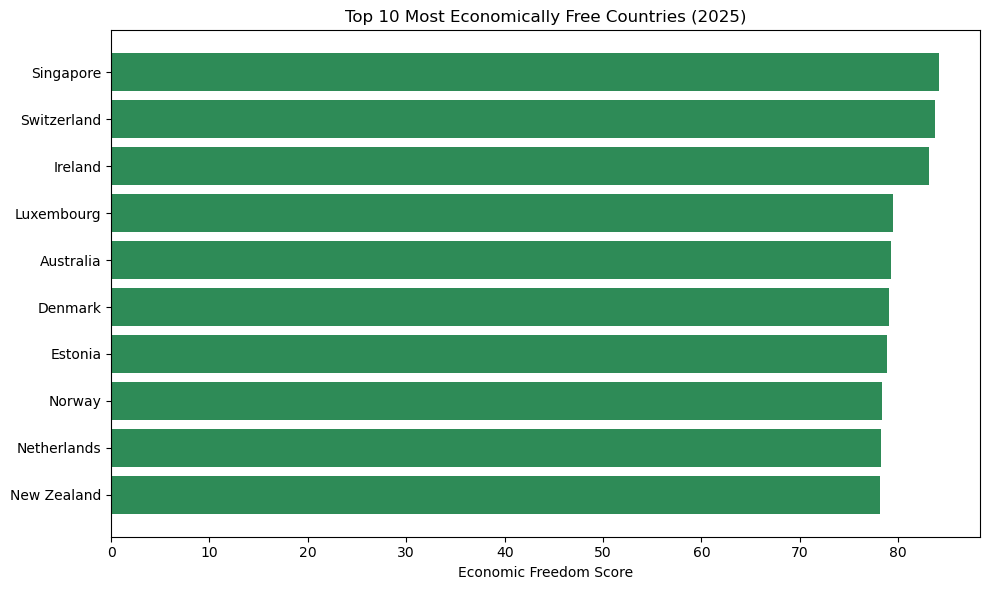

In [7]:
top10_freedom = df[df["Year"] == latest_year].nlargest(10, "Overall Score")

plt.figure(figsize=(10, 6))
plt.barh(
    top10_freedom["Country Name"],
    top10_freedom["Overall Score"],
    color="seagreen",
)
plt.xlabel("Economic Freedom Score")
plt.title(f"Top 10 Most Economically Free Countries ({latest_year})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

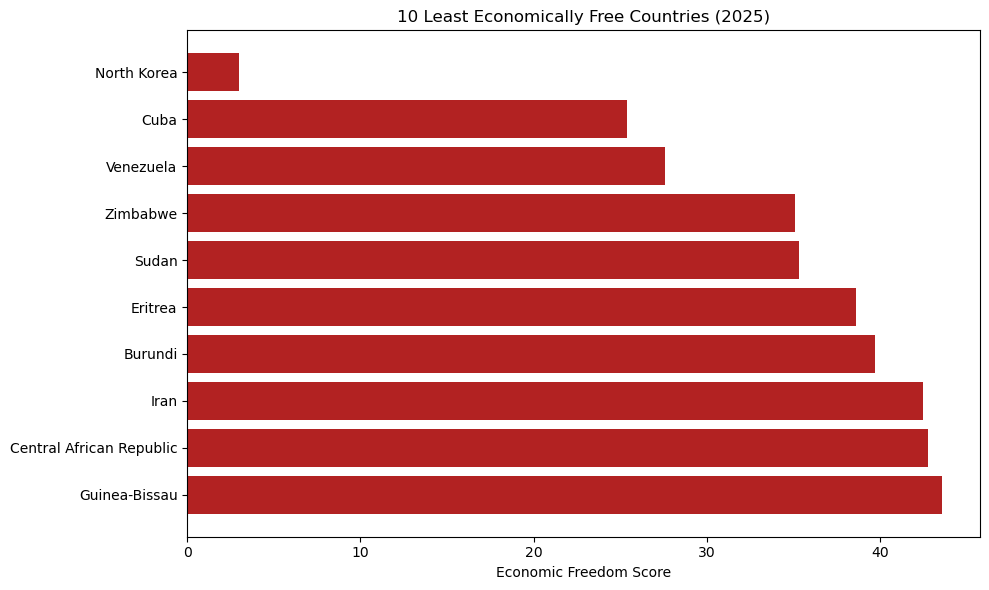

In [8]:
bottom10_freedom = df[df["Year"] == latest_year].nsmallest(10, "Overall Score")

plt.figure(figsize=(10, 6))
plt.barh(
    bottom10_freedom["Country Name"],
    bottom10_freedom["Overall Score"],
    color="firebrick",
)
plt.xlabel("Economic Freedom Score")
plt.title(f"10 Least Economically Free Countries ({latest_year})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

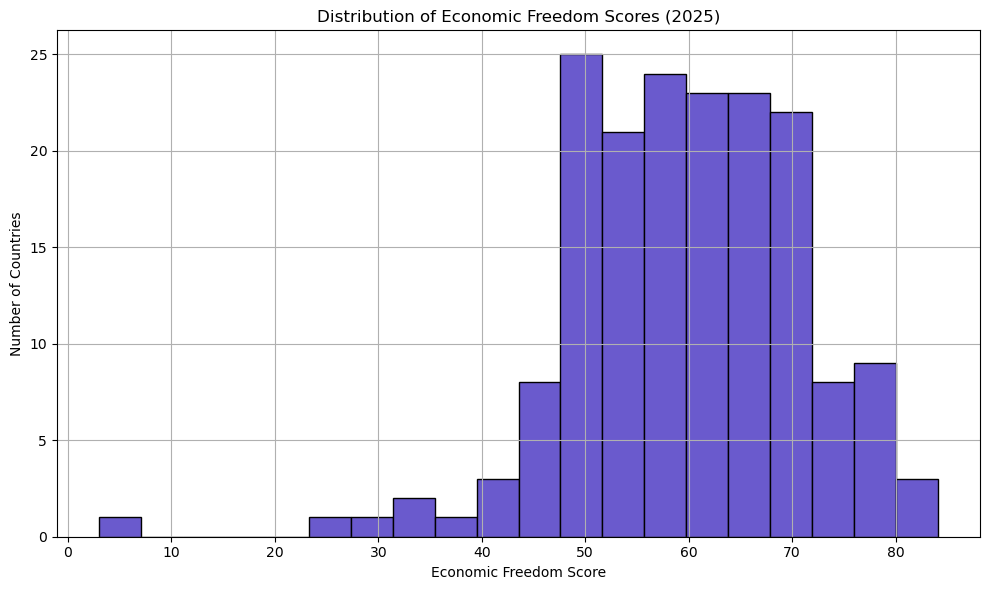

In [9]:
plt.figure(figsize=(10, 6))
df[df["Year"] == latest_year]["Overall Score"].hist(
    bins=20, color="slateblue", edgecolor="black"
)
plt.xlabel("Economic Freedom Score")
plt.ylabel("Number of Countries")
plt.title(f"Distribution of Economic Freedom Scores ({latest_year})")
plt.tight_layout()
plt.show()

In [10]:
def scatter_freedom_development():
    px.scatter(
        df,
        x="Overall Score",
        y="GDP per capita (current US$)",
        hover_name="Country Name",
        animation_frame="Year",
        log_y=True,
        range_y=[100, 250000],
        range_x=[0, 100],
        color="GDP per capita (current US$)",
    ).show()


scatter_freedom_development()

In [11]:
fig = px.choropleth(
    df,
    locations="Country Code",
    color="Overall Score",
    hover_name="Country Name",
    animation_frame="Year",
    color_continuous_scale="RdYlGn",
)

fig.update_layout(
    width=1100,
    height=650,
    title_x=0.5,
    title={
        "text": "Economic Freedom Score by Country",
        "x": 0.5,
        "xanchor": "center",
        "y": 0.95,
        "font": {"size": 25},
    },
)

fig.update_geos(projection_type="natural earth", showcoastlines=True)

fig.show()


## Part III | Relationship Between Economic Freedom and Development Outcomes

Compare countries by economic freedom level against development outcomes such as GDP per capita, life expectancy, and unemployment.

In [ ]:
gdp_col = "GDP per capita (current US$)"

snapshot = df[df["Year"] == latest_year].dropna(
    subset=["Overall Score", gdp_col]
)
continents = sorted(snapshot["Continent"].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
fig.patch.set_facecolor("#fcfcfb")

for ax, continent in zip(axes.flat, continents):
    countries = snapshot[snapshot["Continent"] == continent]

    # Faint backdrop of every country, so the panels stay comparable.
    ax.scatter(
        snapshot["Overall Score"],
        snapshot[gdp_col],
        s=22,
        color="#d8d7d1",
        edgecolor="none",
        zorder=1,
        label="All countries",
    )
    ax.scatter(
        countries["Overall Score"],
        countries[gdp_col],
        s=38,
        color="#2a78d6",
        edgecolor="#fcfcfb",
        linewidth=0.8,
        zorder=2,
        label="Countries in this continent",
    )

    ax.set_title(
        f"{continent}  ·  {len(countries)} countries",
        fontsize=12,
        color="#0b0b0b",
        loc="left",
        pad=10,
    )
    ax.set_yscale("log")
    ax.set_yticks([1e2, 1e3, 1e4, 1e5])
    ax.set_yticklabels(["$100", "$1k", "$10k", "$100k"])
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(which="both", length=0, colors="#898781", labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle(
    f"Economic Freedom vs GDP per Capita by Continent ({latest_year})",
    fontsize=16,
    color="#0b0b0b",
    y=0.98,
)
fig.supxlabel("Economic Freedom Score", fontsize=11, color="#52514e")
fig.supylabel(
    "GDP per Capita (current US$, log scale)", fontsize=11, color="#52514e"
)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.985),
    frameon=False,
    fontsize=10,
    labelcolor="#52514e",
    handletextpad=0.4,
    ncols=2,
)

fig.tight_layout(rect=[0.01, 0.02, 1, 0.94], h_pad=3)
plt.show()

In [ ]:
def usd_short(value, _pos):
    """Format a GDP-per-capita tick as $850 / $2.5k / $100k."""
    return f"${value / 1000:g}k" if value >= 1000 else f"${value:g}"


fig, axes = plt.subplots(3, 2, figsize=(15, 19))
fig.patch.set_facecolor("#fcfcfb")

for ax, continent in zip(axes.flat, continents):
    countries = snapshot[snapshot["Continent"] == continent]

    ax.scatter(
        countries["Overall Score"],
        countries[gdp_col],
        s=42,
        color="#2a78d6",
        edgecolor="#fcfcfb",
        linewidth=0.8,
        zorder=2,
    )
    # Label every country; the halo keeps codes legible over leader lines.
    texts = [
        ax.text(
            row["Overall Score"],
            row[gdp_col],
            row["Country Code"],
            fontsize=7,
            color="#52514e",
            zorder=3,
            path_effects=[pe.withStroke(linewidth=2.5, foreground="#fcfcfb")],
        )
        for _, row in countries.iterrows()
    ]

    ax.set_title(
        f"{continent}  ·  {len(countries)} countries",
        fontsize=13,
        color="#0b0b0b",
        loc="left",
        pad=10,
    )
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(FuncFormatter(usd_short))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=()))
    ax.margins(x=0.11, y=0.09)
    ax.set_xlabel("Economic Freedom Score", fontsize=9, color="#52514e")
    ax.set_ylabel("GDP per Capita (US$, log)", fontsize=9, color="#52514e")
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(which="both", length=0, colors="#898781", labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Run last, so labels are nudged apart against the final axis scaling.
    # Takes ~30s for the whole figure; the dense panels need the iterations.
    adjust_text(
        texts,
        x=countries["Overall Score"].to_numpy(),
        y=countries[gdp_col].to_numpy(),
        ax=ax,
        expand=(1.25, 1.4),
        force_text=(0.4, 0.5),
        max_move=20,
        time_lim=8,
        arrowprops={"arrowstyle": "-", "color": "#c3c2b7", "linewidth": 0.5},
    )

fig.suptitle(
    "Economic Freedom vs GDP per Capita, within each continent "
    f"({latest_year})",
    fontsize=17,
    color="#0b0b0b",
    y=0.995,
)

fig.tight_layout(rect=[0, 0, 1, 0.98], h_pad=3.5, w_pad=3)
plt.show()

## Part IV | Correlation Analysis Across Indicators

Quantify how strongly economic freedom sub-components correlate with development outcomes, to identify the strongest candidate relationships.

## Part V | Key Findings and Takeaways

Summarise the main patterns found in this notebook, to be carried into `III-ml.ipynb`.